# Portfolio Risk Engine
Risk analysis of a multi-asset portfolio using Historical VaR, Parametric VaR and Monte Carlo simulation.

# 1. Portfolio Risk Engine

This project implements a portfolio risk analysis framework using Python.

The objective is to evaluate portfolio risk using multiple approaches, including:

• Historical Value at Risk (VaR)  
• Parametric (Variance-Covariance) VaR  
• Monte Carlo VaR  
• Expected Shortfall (CVaR)  

The project also includes volatility modelling using:

• Rolling historical volatility  
• EWMA volatility  
• GARCH(1,1) conditional volatility  

All calculations are applied to a personal portfolio using historical market data from Yahoo Finance.

In [1]:
!pip install yfinance
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## 2. Define Portfolio Assets
Define the tickers representing the assets in the portfolio.

In [22]:
tickers = [
    "NVDA",
    "GOOGL",
    "AMZN",
    "O",
    "OGS",
    "SPXS",
    "AIR.PA",
    "RHMB.F",
    "DFPP.F"
]

## 3. Download Historical Price Data
Download historical market prices from Yahoo Finance.

In [23]:
prices = yf.download(tickers, start="2020-01-01")
prices = prices["Close"]

prices.head()

/tmp/ipykernel_422/2217258464.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start="2020-01-01")
[*********************100%***********************]  9 of 9 completed


Ticker,AIR.PA,AMZN,DFPP.F,GOOGL,NVDA,O,OGS,RHMB.F,SPXS
Date,,,,,,,,,
2020-01-02,124.759399,94.900497,0.005,67.873016,5.971077,51.921612,75.040123,NaN,1134.587769
2020-01-03,125.245262,93.748497,0.005,67.517967,5.875504,52.860058,75.145660,NaN,1160.113770
2020-01-06,124.703323,95.143997,0.005,69.317589,5.900144,53.125103,74.764061,NaN,1148.671143
2020-01-07,123.339119,95.343002,0.005,69.183693,5.971575,53.139423,73.871033,NaN,1157.473022
2020-01-08,125.562965,94.598503,0.005,69.676132,5.982776,53.382999,73.505699,NaN,1138.988770


## 4. Compute Asset Returns
Compute daily returns from historical price data.

In [24]:
returns = prices.pct_change()
returns = returns.dropna()
returns.head()


/tmp/ipykernel_422/3292644489.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


Ticker,AIR.PA,AMZN,DFPP.F,GOOGL,NVDA,O,OGS,RHMB.F,SPXS
Date,,,,,,,,,
2020-04-06,0.081305,0.047729,0.0,0.082813,0.100406,0.073624,0.101245,0.025210,-0.202279
2020-04-07,0.065571,0.007013,0.0,-0.000533,-0.034910,0.053835,-0.035073,0.008197,-0.003571
2020-04-08,0.048562,0.015609,0.0,0.020667,0.030576,0.077032,0.043593,-0.024390,-0.102509
2020-04-09,0.019896,-0.000117,0.0,-0.000356,-0.014984,0.066817,0.053691,0.033333,-0.047125
2020-04-13,0.000000,0.061735,0.0,0.003183,0.026241,-0.055398,-0.044476,0.000000,0.029338


In [25]:
returns.describe()

Ticker,AIR.PA,AMZN,DFPP.F,GOOGL,NVDA,O,OGS,RHMB.F,SPXS
count,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000
mean,0.001107,0.000767,0.028602,0.001316,0.002726,0.000568,0.000325,0.002762,-0.001908
std,0.021426,0.021828,0.992172,0.019185,0.031586,0.013950,0.015831,0.032426,0.032452
min,-0.114912,-0.140494,-0.535354,-0.095094,-0.169682,-0.085420,-0.176423,-0.137037,-0.280488
25%,-0.009337,-0.010744,-0.032797,-0.008600,-0.014486,-0.006930,-0.008133,-0.013117,-0.019079
50%,0.000805,0.000265,0.000000,0.001053,0.002353,0.000341,0.000507,0.000000,-0.001276
75%,0.010907,0.012361,0.033166,0.011294,0.020082,0.008133,0.008625,0.018696,0.013628
max,0.185714,0.135359,38.720000,0.102244,0.243697,0.077032,0.101245,0.327273,0.179293


## 5. Define Portfolio Weights
Define the weights of each asset in the portfolio.

In [26]:
weights = np.array([1/9,1/9,1/9,1/9,1/9,1/9,1/9,1/9,1/9])

In [27]:
portfolio_returns = returns.dot(weights)
portfolio_returns.name = "Prtf Returns"
portfolio_returns.head()

,Prtf Returns
Date,
2020-04-06,0.034450
2020-04-07,0.006725
2020-04-08,0.012127
2020-04-09,0.012351
2020-04-13,0.002291


## 6. Portfolio Performance
Visualize the cumulative performance of the portfolio over time.

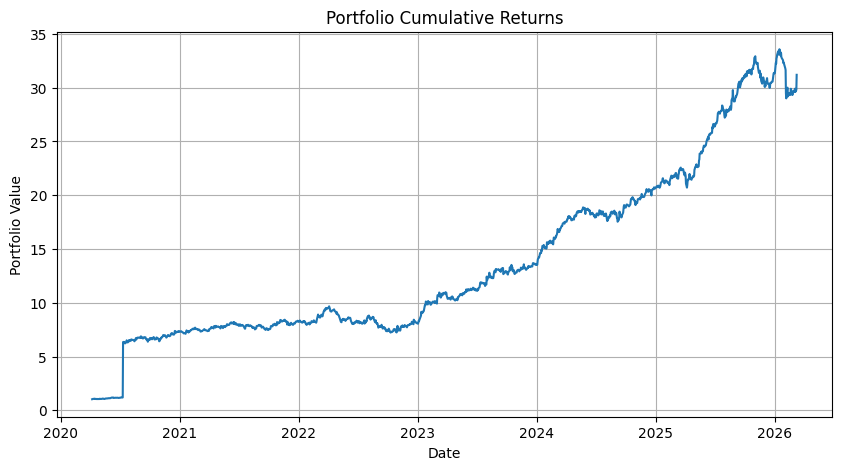

In [28]:
cumulative_returns = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cumulative_returns)
plt.title("Portfolio Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

## 7. Correlation Matrix
Analyze the correlation between assets in the portfolio.

In [30]:
correlation_matrix = returns.corr()

correlation_matrix

Ticker,AIR.PA,AMZN,DFPP.F,GOOGL,NVDA,O,OGS,RHMB.F,SPXS
Ticker,,,,,,,,,
AIR.PA,1.000000,0.082915,0.042007,0.180395,0.122704,0.298981,0.167943,0.167547,-0.337932
AMZN,0.082915,1.000000,0.009761,0.615066,0.556575,0.126901,0.053777,0.030099,-0.678743
DFPP.F,0.042007,0.009761,1.000000,0.017571,-0.003822,-0.002893,0.020375,-0.023267,-0.024126
GOOGL,0.180395,0.615066,0.017571,1.000000,0.530083,0.204918,0.100931,0.028097,-0.694314
NVDA,0.122704,0.556575,-0.003822,0.530083,1.000000,0.084391,-0.001048,0.043090,-0.682228
O,0.298981,0.126901,-0.002893,0.204918,0.084391,1.000000,0.488492,0.072185,-0.451380
OGS,0.167943,0.053777,0.020375,0.100931,-0.001048,0.488492,1.000000,0.076329,-0.337786
RHMB.F,0.167547,0.030099,-0.023267,0.028097,0.043090,0.072185,0.076329,1.000000,-0.086760
SPXS,-0.337932,-0.678743,-0.024126,-0.694314,-0.682228,-0.451380,-0.337786,-0.086760,1.000000


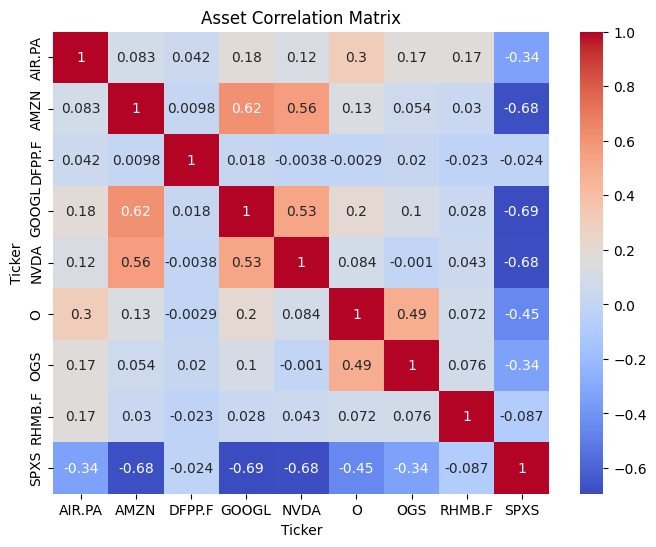

In [31]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Asset Correlation Matrix")
plt.show()

## 8. Distribution of Portfolio Returns
Visualize the distribution of portfolio returns and compare it with a normal distribution.

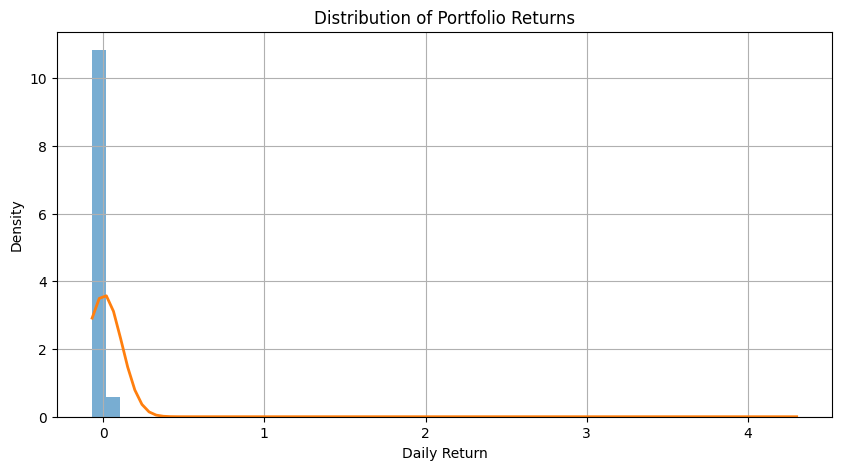

In [32]:
import scipy.stats as stats

plt.figure(figsize=(10,5))

# Histograma de retornos
plt.hist(portfolio_returns, bins=50, density=True, alpha=0.6)

# Ajuste de distribución normal
mu, sigma = portfolio_returns.mean(), portfolio_returns.std()

x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2)

plt.title("Distribution of Portfolio Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.grid(True)

plt.show()

In [33]:
portfolio_returns.sort_values().tail()

,Prtf Returns
Date,
2022-12-20,0.052436
2023-03-02,0.053940
2023-08-01,0.062318
2022-10-31,0.084089
2020-07-10,4.302410


In [34]:
portfolio_returns.sort_values().head()

,Prtf Returns
Date,
2026-02-05,-0.068303
2023-09-21,-0.041895
2022-11-01,-0.036697
2022-07-22,-0.035345
2021-11-26,-0.034305


### Data Cleaning

Since this project uses my personal portfolio, one asset (DFPP) produced an extreme outlier in the daily returns due to low liquidity and data irregularities.  
To avoid distorting the analysis, returns were filtered by capping daily values between -20% and +20%.  
The asset itself is kept in the portfolio, but unrealistic return observations are removed.

In [35]:
portfolio_returns_clean = portfolio_returns[
    (portfolio_returns > -0.2) & (portfolio_returns < 0.2)
]

In [36]:
portfolio_returns_clean.sort_values().tail()

,Prtf Returns
Date,
2023-01-23,0.052224
2022-12-20,0.052436
2023-03-02,0.053940
2023-08-01,0.062318
2022-10-31,0.084089


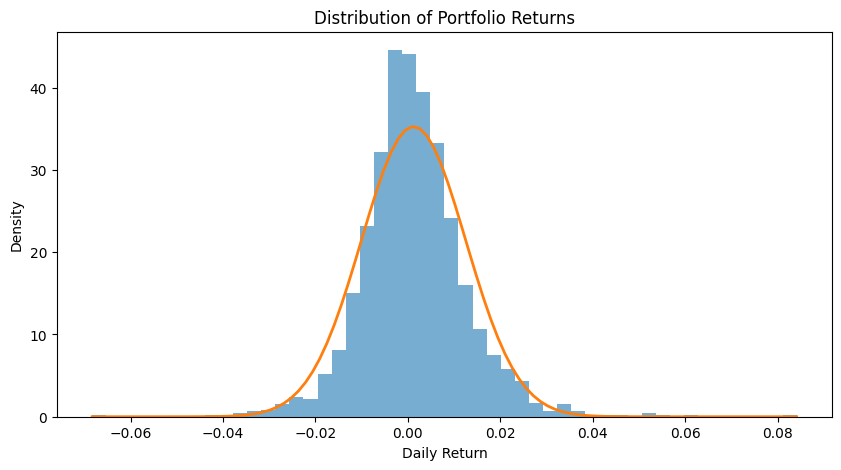

In [37]:
plt.figure(figsize=(10,5))

plt.hist(portfolio_returns_clean, bins=50, density=True, alpha=0.6)

mu = portfolio_returns_clean.mean()
sigma = portfolio_returns_clean.std()

x = np.linspace(portfolio_returns_clean.min(), portfolio_returns_clean.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2)

plt.title("Distribution of Portfolio Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")

plt.show()

## 9. Historical Value at Risk (VaR)

Historical VaR estimates the potential loss of the portfolio using the empirical distribution of historical returns.  
It calculates the percentile of past portfolio returns corresponding to a given confidence level.

In [39]:
confidence_level = 0.95
historical_var = np.percentile(portfolio_returns_clean, (1 - confidence_level) * 100)
historical_var

np.float64(-0.01541725699741028)

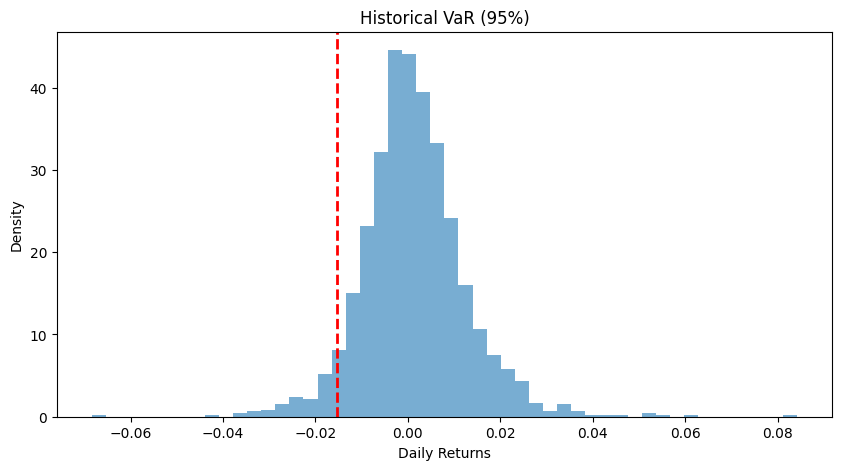

In [40]:
plt.figure(figsize=(10,5))

plt.hist(portfolio_returns_clean, bins=50, density=True, alpha=0.6)

plt.axvline(historical_var, color='red', linestyle='dashed', linewidth=2)

plt.title("Historical VaR (95%)")
plt.xlabel("Daily Returns")
plt.ylabel("Density")

plt.show()

### Interpretation

The 95% Historical VaR of the portfolio is approximately **-1.54%**.

This means that, based on historical data, there is a **95% probability that the portfolio will not lose more than 1.54% in a single day**.

Conversely, in about **5% of trading days**, the portfolio could experience losses greater than this threshold.

## 10. Parametric Value at Risk (Variance-Covariance)

The parametric VaR assumes that portfolio returns follow a normal distribution.  
It estimates the potential loss using the mean and standard deviation of portfolio returns.

In [41]:
confidence_level = 0.95

mu = portfolio_returns_clean.mean()
sigma = portfolio_returns_clean.std()
z_score = stats.norm.ppf(1 - confidence_level)
parametric_var = mu + z_score * sigma
parametric_var

np.float64(-0.017379082260353246)

### Comparison with Historical VaR

The parametric VaR is slightly larger than the historical VaR.  
This occurs because the parametric method assumes normally distributed returns and relies on the estimated volatility of the portfolio.

In portfolios containing volatile assets such as technology stocks and leveraged ETFs, the volatility estimate can produce a slightly more conservative VaR.

## 11. Monte Carlo Value at Risk

Monte Carlo VaR estimates potential portfolio losses by simulating many possible future return scenarios based on the statistical properties of historical returns.

In [42]:
n_simulations = 10000
mu = portfolio_returns_clean.mean()
sigma = portfolio_returns_clean.std()
simulated_returns = np.random.normal(mu, sigma, n_simulations)
monte_carlo_var = np.percentile(simulated_returns, 5)
monte_carlo_var

np.float64(-0.017168659679381214)

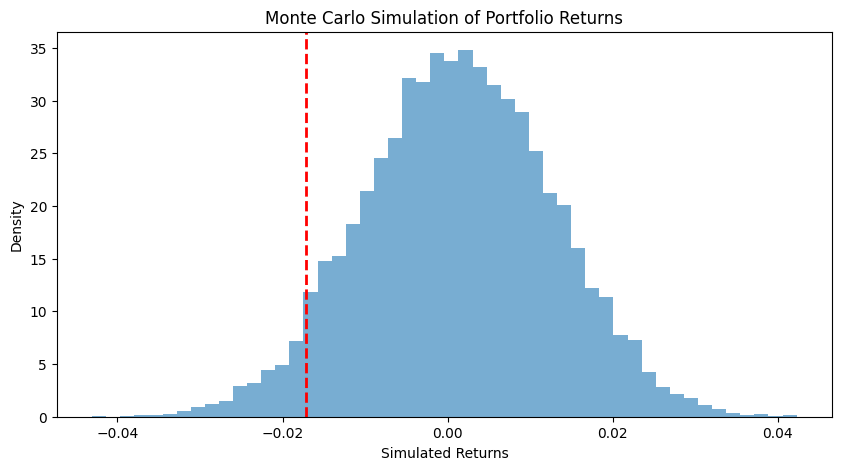

In [43]:
plt.figure(figsize=(10,5))

plt.hist(simulated_returns, bins=50, density=True, alpha=0.6)
plt.axvline(monte_carlo_var, color='red', linestyle='dashed', linewidth=2)
plt.title("Monte Carlo Simulation of Portfolio Returns")
plt.xlabel("Simulated Returns")
plt.ylabel("Density")

plt.show()

### VaR Comparison

The three VaR methods produce similar results, although the parametric and Monte Carlo VaR are slightly more conservative than the historical VaR.

This happens because both methods rely on the estimated mean and volatility of returns and assume a normal distribution, while the historical VaR is based directly on observed portfolio returns.

## 12. VaR Comparison
Compare the risk estimates obtained from the three VaR methodologies.

In [44]:
var_summary = pd.DataFrame({
    "Method": ["Historical VaR", "Parametric VaR", "Monte Carlo VaR"],
    "VaR_95": [historical_var, parametric_var, monte_carlo_var]
})

var_summary

,Method,VaR_95
0,Historical VaR,-0.015417
1,Parametric VaR,-0.017379
2,Monte Carlo VaR,-0.017169


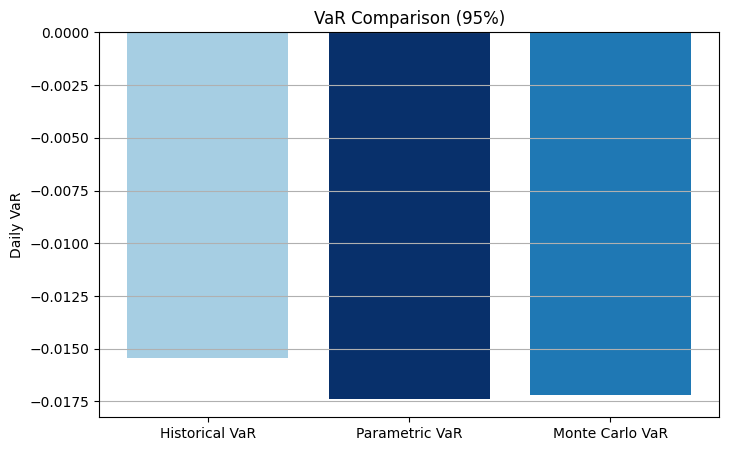

In [47]:
colors = ["#a6cee3", "#08306b", "#1f78b4"]  # claro → medio → oscuro

plt.figure(figsize=(8,5))
plt.bar(var_summary["Method"], var_summary["VaR_95"], color=colors)
plt.title("VaR Comparison (95%)")
plt.ylabel("Daily VaR")
plt.grid(True, axis="y")

plt.show()

## 13. Expected Shortfall (CVaR)

Expected Shortfall measures the **average loss in the worst tail of the return distribution**, beyond the Value at Risk threshold.

While VaR tells us the loss threshold, Expected Shortfall tells us **how large losses are when that threshold is exceeded**.

In [49]:
expected_shortfall = portfolio_returns_clean[
    portfolio_returns_clean <= historical_var
].mean()

expected_shortfall

np.float64(-0.02251726047647281)

In [54]:
var_summary["Expected Shortfall"] = [expected_shortfall]*3

var_summary

,Method,VaR_95,Expected Shortfall,Historical_ES_95
0,Historical VaR,-0.015417,-0.022517,-0.022517
1,Parametric VaR,-0.017379,-0.022517,-0.022517
2,Monte Carlo VaR,-0.017169,-0.022517,-0.022517


### Risk Metrics Interpretation

The portfolio shows a 95% daily VaR between **-1.54% and -1.74%**, depending on the methodology used.

The Historical VaR is slightly lower than the Parametric and Monte Carlo VaR, while the latter two are very similar because both rely on a normal-distribution assumption.

The Historical Expected Shortfall is **-2.25%**, which means that when losses exceed the VaR threshold, the average loss is significantly larger. This highlights the presence of tail risk in the portfolio.

## 14. VaR Backtesting

VaR backtesting evaluates whether the risk model accurately predicts extreme losses.  
For a 95% VaR model, we expect approximately 5% of observations to exceed the VaR threshold.

In [55]:
breaches = portfolio_returns_clean < historical_var

n_breaches = breaches.sum()
total_obs = len(portfolio_returns_clean)

breach_ratio = n_breaches / total_obs

print("Number of breaches:", n_breaches)
print("Total observations:", total_obs)
print("Breach ratio:", breach_ratio)

Number of breaches: 77
Total observations: 1531
Breach ratio: 0.050293925538863485


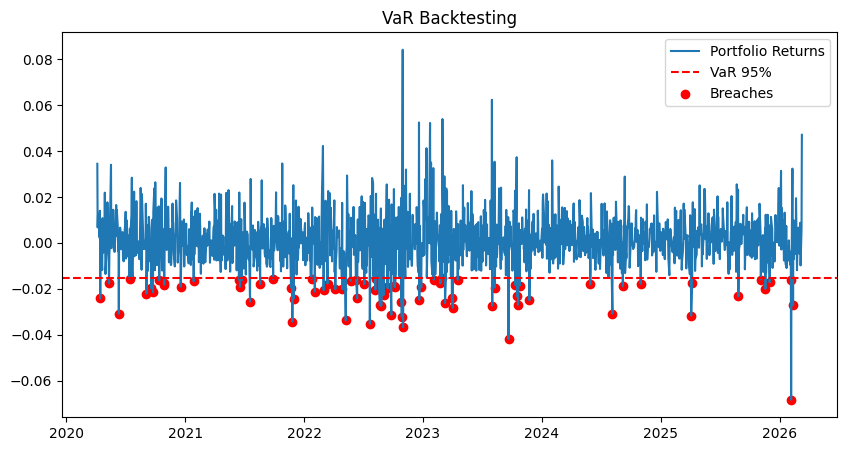

In [56]:
plt.figure(figsize=(10,5))

plt.plot(portfolio_returns_clean, label="Portfolio Returns")

plt.axhline(historical_var, color="red", linestyle="dashed", label="VaR 95%")

plt.scatter(
    portfolio_returns_clean.index[breaches],
    portfolio_returns_clean[breaches],
    color="red",
    label="Breaches"
)

plt.legend()
plt.title("VaR Backtesting")
plt.show()

### VaR Backtesting Results

The backtesting results show 77 breaches out of 1531 observations, corresponding to a breach ratio of approximately 5.03%.

This is extremely close to the expected 5% for a 95% VaR model, suggesting that the Historical VaR is well calibrated and provides a reliable estimate of downside risk for the portfolio.

## 15. Conclusion

This project implemented a portfolio risk analytics framework using multiple Value at Risk methodologies.

Historical, Parametric, and Monte Carlo VaR were computed and compared, followed by Expected Shortfall and backtesting of the VaR model.

The results show that the different approaches produce similar risk estimates, while backtesting confirms that the Historical VaR is well calibrated for the portfolio.

## 15. Volatility Analysis

Before modeling volatility with more advanced methods, we first compute the rolling historical volatility of the portfolio returns.

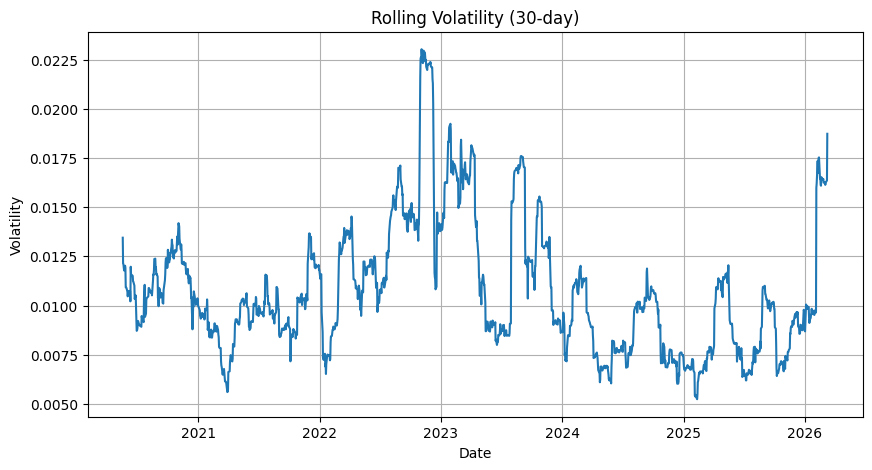

In [58]:
rolling_vol = portfolio_returns_clean.rolling(30).std()

plt.figure(figsize=(10,5))
plt.plot(rolling_vol)
plt.title("Rolling Volatility (30-day)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.grid(True)
plt.show()

## 16. EWMA Volatility

The Exponentially Weighted Moving Average (EWMA) gives more weight to recent observations when estimating volatility.

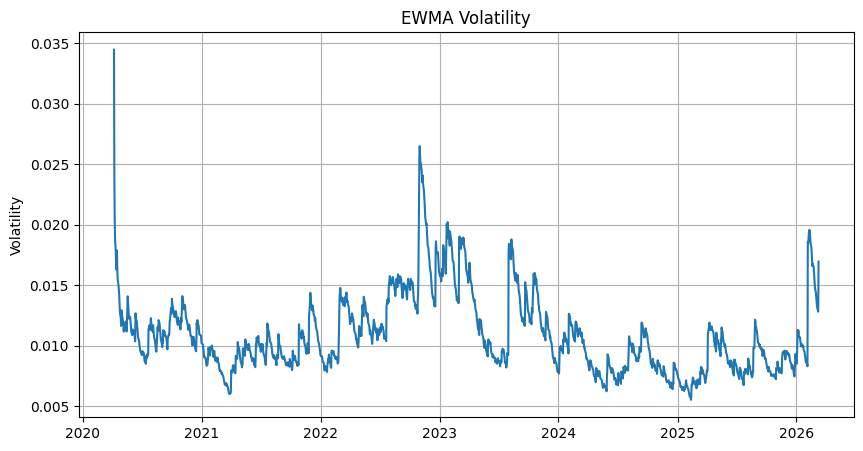

In [59]:
lambda_ = 0.94

ewma_var = portfolio_returns_clean.pow(2).ewm(alpha=1-lambda_).mean()
ewma_vol = np.sqrt(ewma_var)

plt.figure(figsize=(10,5))
plt.plot(ewma_vol)
plt.title("EWMA Volatility")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

## 17. GARCH Volatility

GARCH models capture volatility clustering by modeling conditional variance as a function of past shocks and past volatility.

In [60]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.2 MB/s eta 0:00:00


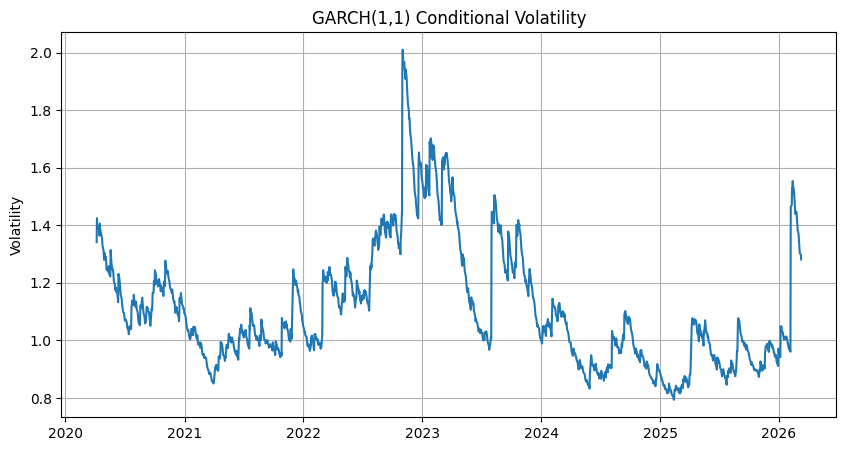

In [61]:
from arch import arch_model

garch_model = arch_model(portfolio_returns_clean*100, vol='Garch', p=1, q=1)

garch_fit = garch_model.fit(disp="off")

garch_vol = garch_fit.conditional_volatility

plt.figure(figsize=(10,5))
plt.plot(garch_vol)
plt.title("GARCH(1,1) Conditional Volatility")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

### Volatility Modelling

Three volatility estimators were compared:

• Rolling historical volatility  
• EWMA volatility  
• GARCH(1,1) conditional volatility  

The results show clear evidence of volatility clustering, a well-known stylized fact of financial markets.

EWMA reacts faster to recent shocks, while the GARCH model captures persistence in volatility and provides a smoother estimate of conditional risk.